# Aula 02 — Do problema ao experimento

**Laboratório:** features, target, splits e baseline  
**Trilha:** Especialista em IA · MirandasTech

[Voltar para a aula](../aulas/02-framing-dataset-split-baseline.md)

## Goal

Demonstrar que um resultado excelente pode ser enganoso quando a divisão dos dados não representa o cenário real de generalização.

Ao final, você terá:

- um dataset sintético reproduzível com entidades repetidas;
- um baseline explícito;
- dois protocolos de avaliação para o mesmo algoritmo;
- um teste automático que garante separação de grupos;
- um gráfico e uma interpretação baseada nos resultados executados.


## tl;dr

Com `random_state=42`, o split aleatório por linha compartilha **168 clientes** entre treino e teste e o modelo atinge **1,00 de balanced accuracy**. Ao reservar clientes inéditos, a interseção cai para **zero** e o resultado do mesmo algoritmo cai para aproximadamente **0,42**, próximo do baseline **0,50**.

O primeiro protocolo mede reconhecimento de identidades já vistas; o segundo mede generalização para clientes novos. O splitter muda a pergunta respondida pela métrica.


## Setup

O notebook usa apenas NumPy, pandas, Matplotlib e scikit-learn. Em Colab, essas bibliotecas já vêm instaladas.

### Key Assumptions

- cada cliente possui cinco registros;
- a classe é fixa por cliente e sorteada sem padrão útil;
- o identificador é usado deliberadamente como feature para criar um memorizer;
- o objetivo declarado é avaliar clientes inéditos;
- balanced accuracy é usada para dar peso igual às duas classes.

Esse é um exemplo sintético e extremo. Ele isola o mecanismo de leakage por entidade; não representa toda a complexidade de um sistema real.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
print(f"Python: {sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")


Python: 3.12.13
scikit-learn: 1.8.0


## Steps

### 1. Declare o contrato de predição

Antes dos dados, defina o que o experimento pretende estimar.


In [2]:
contrato = {
    "decisao": "avaliar uma regra para clientes ainda não observados",
    "unidade": "um registro de cliente",
    "instante_t0": "momento em que o registro chega",
    "target": "classe binária fixa do cliente",
    "features_permitidas": ["cliente_id — incluído apenas para demonstrar memorização"],
    "cenario_de_generalizacao": "clientes inéditos",
    "baseline": "classe mais frequente",
    "metrica": "balanced accuracy",
}

pd.Series(contrato, name="Contrato")


decisao                     avaliar uma regra para clientes ainda não obse...
unidade                                                um registro de cliente
instante_t0                                   momento em que o registro chega
target                                         classe binária fixa do cliente
features_permitidas         [cliente_id — incluído apenas para demonstrar ...
cenario_de_generalizacao                                    clientes inéditos
baseline                                                classe mais frequente
metrica                                                     balanced accuracy
Name: Contrato, dtype: object

### 2. Gere entidades repetidas

Cada cliente recebe uma classe aleatória, repetida em seus cinco registros. Como a classe não segue um padrão no número do cliente, um modelo só pode acertar clientes novos por acaso.


In [3]:
rng = np.random.default_rng(SEED)
n_clientes = 240
linhas_por_cliente = 5

cliente_id = np.repeat(np.arange(n_clientes), linhas_por_cliente)
classe_do_cliente = rng.integers(0, 2, size=n_clientes)
y = np.repeat(classe_do_cliente, linhas_por_cliente)
X = cliente_id.reshape(-1, 1)
indices = np.arange(len(y))

dados = pd.DataFrame({"cliente_id": cliente_id, "target": y})
print(f"Linhas: {len(dados)}")
print(f"Clientes: {dados['cliente_id'].nunique()}")
print(f"Prevalência da classe 1: {dados['target'].mean():.3f}")
dados.head(10)


Linhas: 1200
Clientes: 240
Prevalência da classe 1: 0.500


,cliente_id,target
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


### 3. Crie os dois protocolos

O split por linha parece razoável, mas mistura registros dos mesmos clientes. O split por grupo mantém todas as linhas de um cliente na mesma partição.


In [4]:
treino_linha, teste_linha = train_test_split(
    indices,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
treino_grupo, teste_grupo = next(splitter.split(X, y, groups=cliente_id))

def clientes_compartilhados(treino, teste):
    return set(cliente_id[treino]) & set(cliente_id[teste])

print("Clientes compartilhados — split por linha:", len(clientes_compartilhados(treino_linha, teste_linha)))
print("Clientes compartilhados — split por grupo:", len(clientes_compartilhados(treino_grupo, teste_grupo)))


Clientes compartilhados — split por linha: 168
Clientes compartilhados — split por grupo: 0


### 4. Compare baseline e modelo

O `DummyClassifier` ignora as features. O 1-NN memoriza a classe do cliente sempre que encontra o mesmo identificador no treino.


In [5]:
def avaliar(nome, treino, teste):
    baseline = DummyClassifier(strategy="most_frequent")
    modelo = KNeighborsClassifier(n_neighbors=1)

    baseline.fit(X[treino], y[treino])
    modelo.fit(X[treino], y[treino])

    return {
        "protocolo": nome,
        "baseline": balanced_accuracy_score(y[teste], baseline.predict(X[teste])),
        "modelo": balanced_accuracy_score(y[teste], modelo.predict(X[teste])),
        "clientes_compartilhados": len(clientes_compartilhados(treino, teste)),
        "clientes_no_teste": len(set(cliente_id[teste])),
    }

resultados = pd.DataFrame([
    avaliar("Split por linha", treino_linha, teste_linha),
    avaliar("Split por grupo", treino_grupo, teste_grupo),
])

resultados.round(3)


,protocolo,baseline,modelo,clientes_compartilhados,clientes_no_teste
0,Split por linha,0.5,1.000,168,168
1,Split por grupo,0.5,0.423,0,48


### 5. Visualize a discrepância

Uma barra alta não é evidência suficiente. Leia o gráfico junto com o número de entidades compartilhadas.


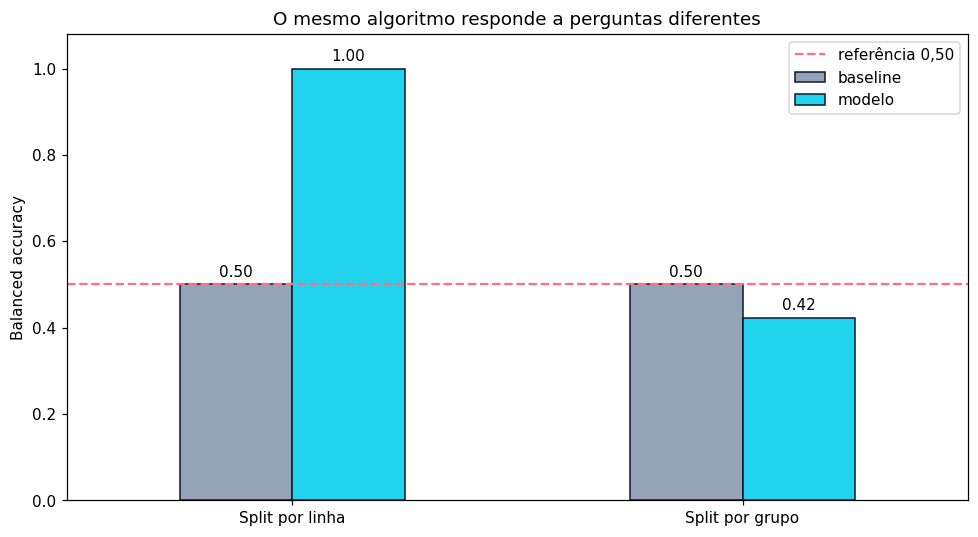

In [6]:
comparacao = resultados.set_index("protocolo")[["baseline", "modelo"]]
ax = comparacao.plot.bar(figsize=(9, 5), color=["#94a3b8", "#22d3ee"], edgecolor="#0f172a")
ax.axhline(0.5, color="#fb7185", linestyle="--", linewidth=1.5, label="referência 0,50")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Balanced accuracy")
ax.set_xlabel("")
ax.set_title("O mesmo algoritmo responde a perguntas diferentes")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()


## Checks

Transforme premissas metodológicas em testes automáticos. Se algum `assert` falhar, o protocolo não atende ao contrato.


In [7]:
assert len(clientes_compartilhados(treino_grupo, teste_grupo)) == 0
assert len(clientes_compartilhados(treino_linha, teste_linha)) > 0
assert resultados.loc[0, "modelo"] > 0.95
assert resultados.loc[1, "modelo"] < 0.65
assert np.isclose(resultados["baseline"], 0.5).all()

print("✓ Grupos estão separados no protocolo por entidade.")
print("✓ O protocolo por linha expõe a memorização deliberada.")
print("✓ O resultado honesto permanece próximo do baseline.")


✓ Grupos estão separados no protocolo por entidade.
✓ O protocolo por linha expõe a memorização deliberada.
✓ O resultado honesto permanece próximo do baseline.


## Takeaways

1. **O splitter é parte da hipótese.** Split por linha estima novas linhas de clientes conhecidos; split por grupo estima clientes inéditos.
2. **Um score perfeito pode ser um alerta.** O resultado de 1,00 surgiu de identidade compartilhada, não de um padrão transferível.
3. **Baseline dá contexto.** Para clientes novos, o modelo de memorização não demonstra ganho confiável sobre 0,50.
4. **Invariantes devem virar código.** O `assert` de interseção vazia protege o objetivo declarado.
5. **Este experimento não prova desempenho de produção.** Os dados são sintéticos e não incluem mudança temporal, ruído de rótulo ou custo operacional.


## Next Steps

- Troque `cliente_id` por uma feature operacional fraca e compare o resultado.
- Faça uma ablação: remova a identidade antes do split por linha e observe a queda.
- Simule datas e crie um corte temporal sem embaralhamento.
- Escreva o contrato de predição para um dataset do AI Systems Laboratory.
- Na Aula 03, coloque transformações dentro de um `Pipeline` para impedir leakage de preprocessing.
